<a href="https://colab.research.google.com/github/smonodeep/DynamicValuationGovernance/blob/main/0.Data_Prep_CityWise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data prep code

In [40]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [41]:
rbi_hpi_path = '/content/House Price Index Publication_RBI.xlsx'

try:
    # Read only the specified range for the 2010-11 HPI block
    df_hpi_raw = pd.read_excel(rbi_hpi_path, sheet_name='House Price Index', header=None, skiprows=27, nrows=61, usecols='B:M')
    print(f"Successfully loaded RBI HPI Excel from {rbi_hpi_path}")
    # Display first few rows to verify loading
    print("Raw HPI data from specified range:")
    display(df_hpi_raw.head())
except FileNotFoundError:
    print(f"Error: RBI HPI Excel file not found at {rbi_hpi_path}")
    df_hpi_raw = pd.DataFrame()
except Exception as e:
    print(f"Error loading RBI HPI Excel: {e}")
    df_hpi_raw = pd.DataFrame()

Successfully loaded RBI HPI Excel from /content/House Price Index Publication_RBI.xlsx
Raw HPI data from specified range:


,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,Ahmedabad,Bangalore,Chennai*,Delhi,Jaipur,Kanpur,Kochi,Kolkata,Lucknow,Mumbai,All India
1,Q1.2010-11,93.218679,98.639697,102.731254,100.721966,95.312154,91.735054,89.611743,77.879138,88.82087,90.626706,94.239884
2,Q2.2010-11,102.54263,97.902562,109.501643,95.560697,99.047963,99.446163,92.376464,103.191573,98.671878,99.717032,99.811033
3,Q3.2010-11,101.99031,97.935658,94.647711,92.105168,103.574958,103.686822,113.849679,106.617769,104.745752,100.879902,99.404514
4,Q4.2010-11,102.248381,105.522082,93.119392,112.058101,102.064925,105.13196,104.162114,112.31152,107.761499,108.77636,106.63229


In [42]:
if not df_hpi_raw.empty:
    df_hpi = df_hpi_raw.copy()

    # The first row contains city names, the first column contains quarter labels
    city_names = df_hpi.iloc[0, 1:].tolist()
    # quarter_labels are in the first column, from the second row onwards
    # No need to extract quarter_labels explicitly here as they will be in the 'quarter' column after column setting

    # Set column names
    df_hpi.columns = ['quarter'] + city_names

    # Drop the first row (city names are now headers)
    df_hpi = df_hpi.drop(df_hpi.index[0])

    # Reset index
    df_hpi = df_hpi.reset_index(drop=True)

    # Convert wide format to long format
    df_hpi_long = df_hpi.melt(id_vars=['quarter'], var_name='city', value_name='hpi')

    # Ensure quarter and city are strings and hpi is numeric
    df_hpi_long['quarter'] = df_hpi_long['quarter'].astype(str)
    df_hpi_long['city'] = df_hpi_long['city'].astype(str)
    df_hpi_long['hpi'] = pd.to_numeric(df_hpi_long['hpi'], errors='coerce')

    print("HPI data after initial cleaning and melt:")
    display(df_hpi_long.head())
else:
    print("df_hpi_raw is empty, skipping HPI cleaning.")
    df_hpi_long = pd.DataFrame()

HPI data after initial cleaning and melt:


,quarter,city,hpi
0,Q1.2010-11,Ahmedabad,93.218679
1,Q2.2010-11,Ahmedabad,102.542630
2,Q3.2010-11,Ahmedabad,101.990310
3,Q4.2010-11,Ahmedabad,102.248381
4,Q1.2011-12,Ahmedabad,121.296551


In [43]:
if not df_hpi_long.empty:
    # 1. Lowercase city names, remove '*' and strip whitespace
    df_hpi_long['city'] = df_hpi_long['city'].str.lower().str.replace('*', '', regex=False).str.strip()

    # 2. Remove 'all india' and NaN HPI values
    df_hpi_long = df_hpi_long[df_hpi_long['city'] != 'all india']
    df_hpi_long = df_hpi_long.dropna(subset=['hpi'])

    # 3. Retain only specified cities
    common_cities = ['bangalore', 'chennai', 'delhi', 'mumbai']
    df_hpi_long = df_hpi_long[df_hpi_long['city'].isin(common_cities)].reset_index(drop=True)

    print("HPI data after standardization and city filtering:")
    print(f"Shape: {df_hpi_long.shape}")
    print(f"Unique cities: {df_hpi_long['city'].unique()}")
    display(df_hpi_long.head())
else:
    print("df_hpi_long is empty, skipping HPI standardization.")

HPI data after standardization and city filtering:
Shape: (240, 3)
Unique cities: ['bangalore' 'chennai' 'delhi' 'mumbai']


,quarter,city,hpi
0,Q1.2010-11,bangalore,98.639697
1,Q2.2010-11,bangalore,97.902562
2,Q3.2010-11,bangalore,97.935658
3,Q4.2010-11,bangalore,105.522082
4,Q1.2011-12,bangalore,110.679615


In [45]:
import re

def parse_rbi_quarter(quarter_str):
    if pd.isna(quarter_str):
        return pd.NaT

    # Regex to capture Q number, 4-digit year, optional 2-digit year for financial year, and optional (P)** suffix
    # It's flexible with separator ('.' or space) and optional financial year part
    match = re.match(r'Q([1-4])[\.\s](\d{4})(?:-(\d{2}))?(?:\(P\)\*\*)?', str(quarter_str))
    if match:
        q_num = int(match.group(1))
        start_year = int(match.group(2))
        # For financial year format like 2010-11, the first year is the start of the financial year.
        # Q1 (April-June) and Q2 (July-Sept) fall in the *first* calendar year of the financial year.
        # Q3 (Oct-Dec) and Q4 (Jan-Mar) fall in the *second* calendar year of the financial year.
        # For calendar year format (YYYY only), year is just start_year.

        # Default to start_year for calendar year and Q1/Q2 of financial year
        calendar_year = start_year

        if match.group(3): # This means it's a financial year format like 2010-11
            if q_num in [3, 4]: # Q3 (Oct-Dec) and Q4 (Jan-Mar) of financial year YYYY-YY fall in YYYY+1 calendar year
                calendar_year = start_year + 1

        return f"{calendar_year}Q{q_num}"
    return pd.NaT

if not df_hpi_long.empty:
    # Apply the improved parsing function
    df_hpi_long['quarter_period'] = df_hpi_long['quarter'].apply(parse_rbi_quarter)

    # Convert quarter_period to pandas Period objects for proper merging and sorting
    # Ensure the frequency is quarterly (Q-DEC for end of December quarter)
    df_hpi_long['quarter_period'] = pd.PeriodIndex(df_hpi_long['quarter_period'], freq='Q-DEC')

    # Drop rows where quarter_period could not be parsed
    df_hpi_long.dropna(subset=['quarter_period'], inplace=True)

    # Ensure quarter_period is sorted for correct growth calculation later
    df_hpi_long = df_hpi_long.sort_values(by=['city', 'quarter_period']).reset_index(drop=True)

    print("HPI data after quarter period standardization:")
    print(f"Shape: {df_hpi_long.shape}")
    print(f"Unique quarters: {df_hpi_long['quarter_period'].nunique()}")
    display(df_hpi_long.head())
else:
    print("df_hpi_long is empty, skipping quarter standardization.")

# Ensure df_rent_agg's quarter_period is also Period type (should already be from previous steps, but re-confirm)
if not df_rent_agg.empty and not pd.api.types.is_period_dtype(df_rent_agg['quarter_period']):
    df_rent_agg['quarter_period'] = pd.PeriodIndex(df_rent_agg['quarter_period'], freq='Q-DEC')
    print("\nConverted df_rent_agg['quarter_period'] to PeriodIndex.")

# Calculate HPI growth (Quarter-over-Quarter)
if not df_hpi_long.empty:
    df_hpi_long['hpi_growth'] = df_hpi_long.groupby('city')['hpi'].pct_change() * 100
    print("\nHPI data with growth calculation:")
    display(df_hpi_long.head())

# Merge HPI and Rent data
# First, align rent and HPI data to common cities and quarters
if not df_hpi_long.empty and not df_rent_agg.empty:
    df_panel = pd.merge(df_hpi_long.rename(columns={'hpi': 'hpi_value'}),
                        df_rent_agg,
                        on=['city', 'quarter_period'],
                        how='inner')
    print("\nPanel data after merging HPI and Rent:")
    print(f"Shape: {df_panel.shape}")
    display(df_panel.head())
else:
    print("HPI or Rent data is empty, skipping merge.")
    df_panel = pd.DataFrame()

# Merge with Repo Rate data
if not df_panel.empty and not df_repo_quarterly.empty:
    df_panel = pd.merge(df_panel,
                        df_repo_quarterly,
                        on='quarter_period',
                        how='left')

    # Diagnostic for repo rate merge
    merge_diagnostics_repo = df_panel[df_panel['repo_rate'].isna()]
    if not merge_diagnostics_repo.empty:
        print(f"\nWarning: {len(merge_diagnostics_repo)} rows have missing repo_rate after merge.")
        # Optionally display some of these rows
        # display(merge_diagnostics_repo.head())

    print("\nPanel data after merging Repo Rate:")
    print(f"Shape: {df_panel.shape}")
    display(df_panel.head())
else:
    print("Panel or Repo Rate data is empty, skipping merge.")

# Calculate valuation gap (assuming a simple ratio for now)
if not df_panel.empty:
    df_panel['valuation_gap'] = df_panel['hpi_value'] / df_panel['rent']
    print("\nPanel data with Valuation Gap:")
    display(df_panel.head())
else:
    print("df_panel is empty, skipping valuation gap calculation.")


# Final filtering and validation (simplified for now)
if not df_panel.empty:
    # Drop rows with any NaN in critical columns if they are not expected
    # For this exercise, let's keep all. Real-world might require dropping NaNs for HPI/Rent growth or valuation gap
    # df_final = df_panel.dropna(subset=['hpi_growth', 'rent_growth', 'valuation_gap'])

    df_final = df_panel.copy()
    df_final_model_dataset = df_panel.copy()

    print("\nFinal data for analysis:")
    print(f"Shape: {df_final.shape}")
    print("Columns:", df_final.columns.tolist())
    display(df_final.head())
else:
    print("df_panel is empty, final dataframes will be empty.")
    df_final = pd.DataFrame()
    df_final_model_dataset = pd.DataFrame()

HPI data after quarter period standardization:
Shape: (240, 5)
Unique quarters: 60


,quarter,city,hpi,quarter_period,hpi_growth
0,Q1.2010-11,bangalore,98.639697,2010Q1,NaN
1,Q2.2010-11,bangalore,97.902562,2010Q2,-0.747300
2,Q1.2011-12,bangalore,110.679615,2011Q1,13.050785
3,Q2.2011-12,bangalore,107.833929,2011Q2,-2.571103
4,Q3.2010-11,bangalore,97.935658,2011Q3,-9.179180



HPI data with growth calculation:


,quarter,city,hpi,quarter_period,hpi_growth
0,Q1.2010-11,bangalore,98.639697,2010Q1,NaN
1,Q2.2010-11,bangalore,97.902562,2010Q2,-0.747300
2,Q1.2011-12,bangalore,110.679615,2011Q1,13.050785
3,Q2.2011-12,bangalore,107.833929,2011Q2,-2.571103
4,Q3.2010-11,bangalore,97.935658,2011Q3,-9.179180



Panel data after merging HPI and Rent:
Shape: (180, 7)


...

,quarter,city,hpi_value,quarter_period,hpi_growth,rent,rent_growth,repo_rate
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,NaN,8.804847
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,0.079504,8.791340
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,-0.084140,8.569230
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,0.098923,8.181552
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,-0.050749,7.782887



Panel data with Valuation Gap:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,rent_growth,repo_rate,valuation_gap
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,NaN,8.804847,1.804000
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,0.079504,8.791340,1.612561
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,-0.084140,8.569230,1.700433
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,0.098923,8.181552,1.677039
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,-0.050749,7.782887,1.995392



Final data for analysis:
Shape: (180, 9)
Columns: ['quarter', 'city', 'hpi_value', 'quarter_period', 'hpi_growth', 'rent', 'rent_growth', 'repo_rate', 'valuation_gap']


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,rent_growth,repo_rate,valuation_gap
0,Q1.2014-15,bangalore,180.400000,2014Q1,27.099900,100.0000,NaN,8.804847,1.804000
1,Q2.2014-15,bangalore,174.600000,2014Q2,-3.215078,108.2750,0.079504,8.791340,1.612561
2,Q3.2013-14,bangalore,169.256843,2014Q3,-3.060227,99.5375,-0.084140,8.569230,1.700433
3,Q4.2013-14,bangalore,184.285621,2014Q4,8.879274,109.8875,0.098923,8.181552,1.677039
4,Q1.2015-16,bangalore,208.418714,2015Q1,13.095483,104.4500,-0.050749,7.782887,1.995392


Summary Stats of the above dataset

In [46]:
if not df_final.empty:
    print("Summary Statistics for the Final Dataset:")
    display(df_final.describe(include='all'))
else:
    print("df_final is empty, cannot provide summary statistics.")

Summary Statistics for the Final Dataset:


,quarter,city,hpi_value,quarter_period,hpi_growth,rent,rent_growth,repo_rate,valuation_gap
count,180,180,180.000000,180,180.000000,180.000000,176.000000,180.000000,180.000000
unique,45,4,NaN,45,NaN,NaN,NaN,NaN,NaN
top,Q1.2014-15,bangalore,NaN,2014Q1,NaN,NaN,NaN,NaN,NaN
freq,4,45,NaN,4,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,270.958459,NaN,1.884594,127.553115,0.010280,7.169236,2.160799
std,NaN,NaN,52.349286,NaN,7.481813,23.814589,0.052487,0.687218,0.455177
min,NaN,NaN,166.502128,NaN,-15.906877,94.500000,-0.248842,5.910980,1.493861
25%,NaN,NaN,227.004840,NaN,-2.518057,109.430357,-0.010513,6.676732,1.794634
50%,NaN,NaN,274.524789,NaN,0.574642,121.650000,0.008223,7.153487,1.966457
75%,NaN,NaN,314.865436,NaN,4.455993,140.700000,0.028091,7.657853,2.521451


Create Visualizations

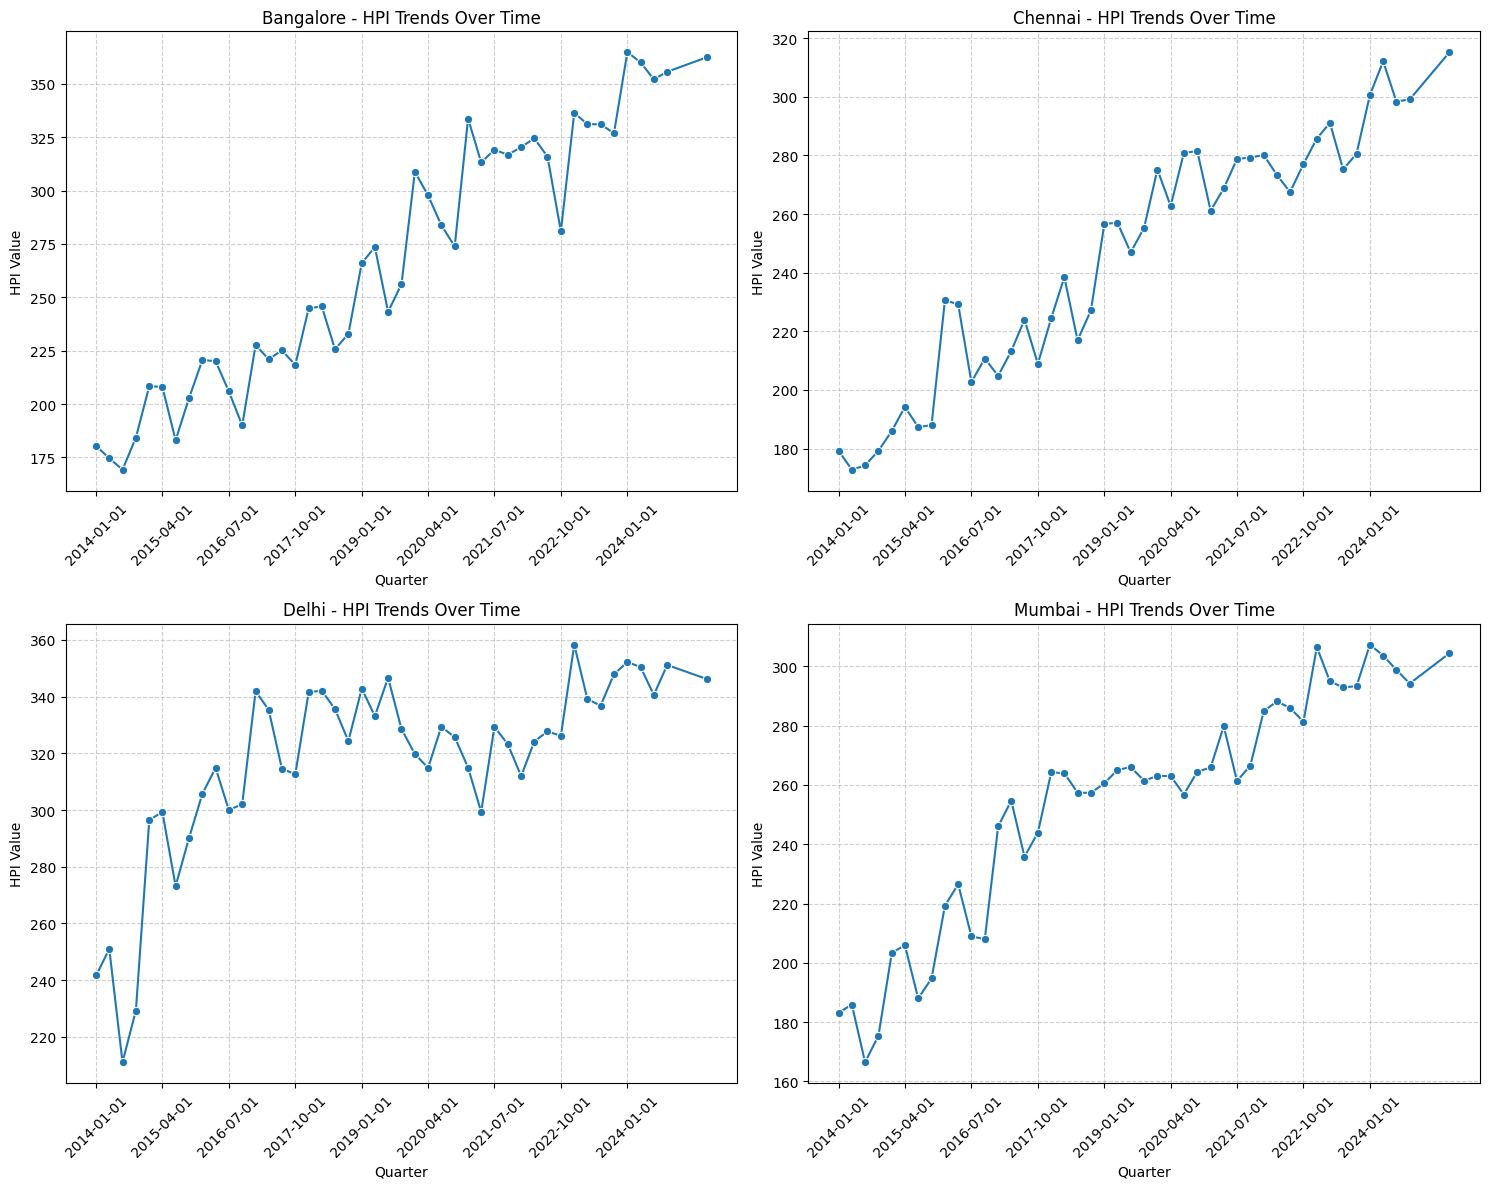

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already globally available

if not df_final.empty:
    cities = df_final['city'].unique()
    n_cities = len(cities)

    # Determine the grid size for subplots
    # For 4 cities, a 2x2 grid is ideal
    n_rows = (n_cities + 1) // 2 if n_cities > 0 else 0 # 2 rows for 3 or 4 cities, 1 for 1 or 2
    n_cols = 2 if n_cities > 1 else 1

    if n_cities > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), squeeze=False)
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, city in enumerate(cities):
            city_data = df_final[df_final['city'] == city].sort_values(by='quarter_period').copy()

            # Convert PeriodIndex to datetime for plotting compatibility
            city_data['quarter_plot'] = city_data['quarter_period'].dt.to_timestamp()

            sns.lineplot(x='quarter_plot', y='hpi_value', data=city_data, ax=axes[i], marker='o', hue='city', legend=False)
            axes[i].set_title(f'{city.capitalize()} - HPI Trends Over Time')
            axes[i].set_xlabel('Quarter')
            axes[i].set_ylabel('HPI Value')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)
            # Adjust x-axis ticks to show fewer labels if there are too many quarters
            if len(city_data['quarter_plot']) > 10:
                # Show every Nth tick for better readability
                n_ticks = len(city_data['quarter_plot'])
                tick_interval = max(1, n_ticks // 8) # Show about 8 ticks
                axes[i].set_xticks(city_data['quarter_plot'][::tick_interval])

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No data in df_final to plot.")
else:
    print("df_final is empty, skipping HPI trend visualization.")

plot hpi growth

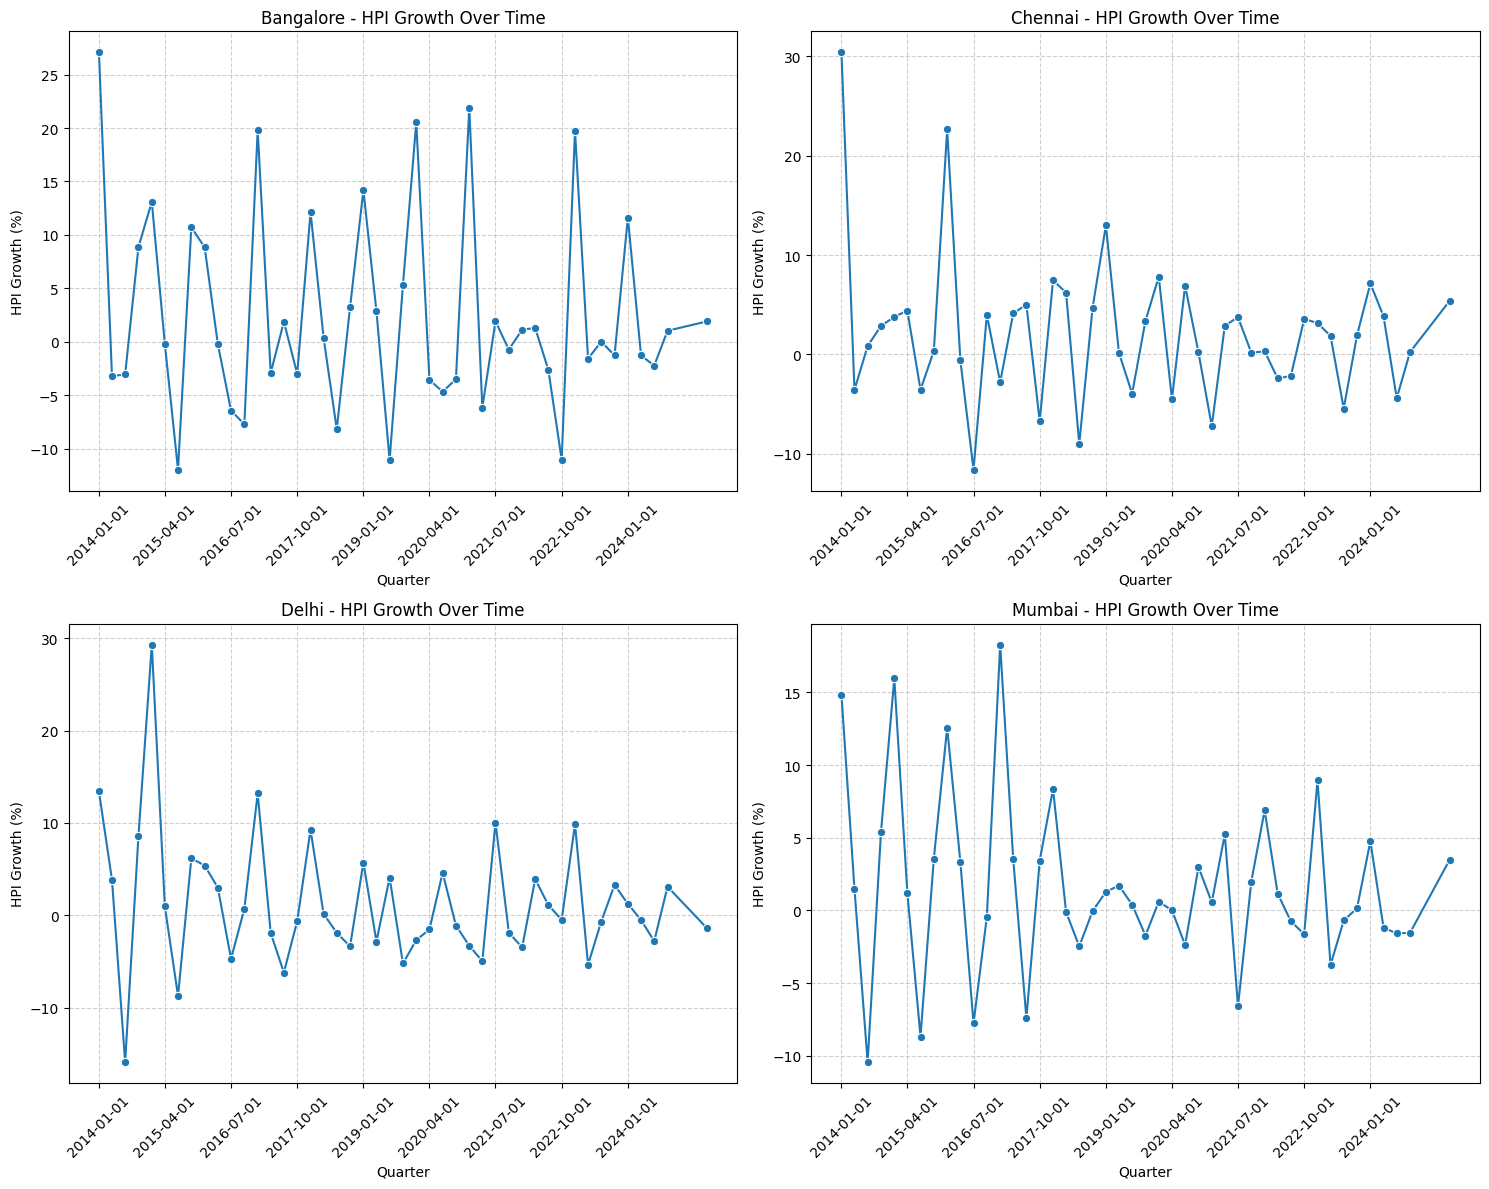

In [50]:
if not df_final.empty:
    cities = df_final['city'].unique()
    n_cities = len(cities)

    # Determine the grid size for subplots
    n_rows = (n_cities + 1) // 2 if n_cities > 0 else 0
    n_cols = 2 if n_cities > 1 else 1

    if n_cities > 0:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows), squeeze=False)
        axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

        for i, city in enumerate(cities):
            city_data = df_final[df_final['city'] == city].sort_values(by='quarter_period').copy()

            # Convert PeriodIndex to datetime for plotting compatibility
            city_data['quarter_plot'] = city_data['quarter_period'].dt.to_timestamp()

            sns.lineplot(x='quarter_plot', y='hpi_growth', data=city_data, ax=axes[i], marker='o', hue='city', legend=False)
            axes[i].set_title(f'{city.capitalize()} - HPI Growth Over Time')
            axes[i].set_xlabel('Quarter')
            axes[i].set_ylabel('HPI Growth (%)')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(True, linestyle='--', alpha=0.6)
            # Adjust x-axis ticks to show fewer labels if there are too many quarters
            if len(city_data['quarter_plot']) > 10:
                n_ticks = len(city_data['quarter_plot'])
                tick_interval = max(1, n_ticks // 8)
                axes[i].set_xticks(city_data['quarter_plot'][::tick_interval])

        # Hide any unused subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    else:
        print("No data in df_final to plot HPI growth.")
else:
    print("df_final is empty, skipping HPI growth visualization.")